In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn import metrics
import pickle

In [2]:
data=pd.read_csv('out time separated 2.csv')
data=data.sample(frac=1)
data = data[data['Successful_Read'] == True]
data = data[data['Shape'] == 'kare']
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Shape,...,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count,Folder,Successful_Read
97072,97072,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,kare,...,45.97,4.78,22.85,0.50,4500,cs,1,0,"detektor data 2/ARNCO2/Kare/Kare 6,78X6,78/4,7...",True
3533,3533,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,kare,...,100.00,6.00,36.00,0.36,7000,cs,15,139,detektor data 2/P10/Kare/Kare 10x10/6x6/p10 70...,True
68884,68884,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,kare,...,45.97,4.78,22.85,0.50,7500,cs,5,251,"detektor data 2/P20/Kare/Kare 6,78X6,78/4,78x4...",True
18449,18449,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,kare,...,100.00,8.00,64.00,0.64,2500,cs,1,0,detektor data 2/P10/Kare/Kare 10x10/8x8/p10 25...,True
92403,92403,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,kare,...,100.00,8.00,64.00,0.64,5000,cs,1,0,detektor data 2/ARNCO2/Kare/Kare 10x10/8x8/500...,True


In [3]:
data=data.sample(frac=1)
#data= data[data['Detector_Size'] == 10]
#data.drop(['Unnamed: 0','Shape','Detector_Size','Cover_Size','CH4','CO2'],axis=1,inplace=True)
#data= data.set_index('Event')


#data= data[data['Gas_Type'] != 'p10']
data.drop(['Shape','Folder','Successful_Read'],axis=1,inplace=True)


data = data[data['Time_Window'].isin([10, 15, 25])]
#data.drop(['Time_Window'],axis=1,inplace=True)



#data= data[(data['Voltage'] >= 4500) & (data['Voltage'] <= 5500)]
#data= data[data['Detector_Size'] == 10]

#data.drop(['Voltage'],axis=1,inplace=True)


In [4]:
#groupByData = data.groupby(['Gas_Type', 'Detector_Size','Cover_Size','Voltage','Time_Window','Source'])

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7370 entries, 4232 to 52857
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7370 non-null   int64  
 1   Gas_Type          7370 non-null   object 
 2   CH4               7370 non-null   float64
 3   Ar                7370 non-null   float64
 4   N2                7370 non-null   float64
 5   CO2               7370 non-null   float64
 6   C                 7370 non-null   float64
 7   O                 7370 non-null   float64
 8   H                 7370 non-null   float64
 9   Detector_Size     7370 non-null   float64
 10  Detector_Area     7370 non-null   float64
 11  Cover_Size        7370 non-null   float64
 12  Cover_Area        7370 non-null   float64
 13  Cover_Area_Ratio  7370 non-null   float64
 14  Voltage           7370 non-null   int64  
 15  Source            7370 non-null   object 
 16  Time_Window       7370 non-null   int64  
 

In [6]:
data.isnull()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
4232,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
57113,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4234,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
56639,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
61122,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
19322,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8961,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
91798,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
data.isnull().sum()

Unnamed: 0          0
Gas_Type            0
CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

<Axes: >

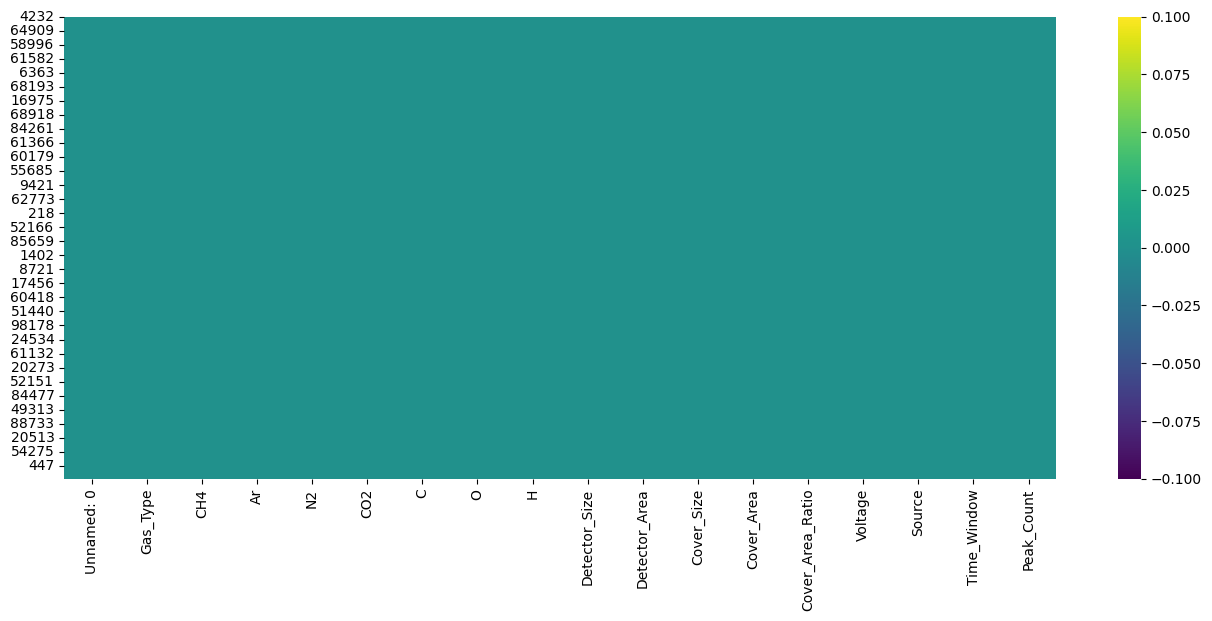

In [8]:
plt.figure(figsize=(16, 6))
sns.heatmap(data.isnull(),cmap='viridis')

In [9]:
data.dropna(inplace=True)

In [10]:
data.isnull().sum()

Unnamed: 0          0
Gas_Type            0
CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

In [11]:
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
4232,4232,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,7500,kaynaksız,10,21
57113,57113,p20,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,100.0,4.0,16.0,0.16,7000,cs,15,215
4234,4234,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,7500,kaynaksız,15,27
56639,56639,p20,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,100.0,4.0,16.0,0.16,4500,kaynaksız,15,10
61122,61122,p20,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,100.0,8.0,64.0,0.64,8000,kaynaksız,15,33


In [12]:
type2=pd.get_dummies(data['Gas_Type'],dtype=float)
type2

,arnco2,p10,p20
4232,0.0,1.0,0.0
57113,0.0,0.0,1.0
4234,0.0,1.0,0.0
56639,0.0,0.0,1.0
61122,0.0,0.0,1.0
...,...,...,...
100996,1.0,0.0,0.0
19322,0.0,1.0,0.0
8961,0.0,1.0,0.0
91798,1.0,0.0,0.0


In [13]:
type=pd.get_dummies(data['Source'],dtype=float)
type

,cs,kaynaksız
4232,0.0,1.0
57113,1.0,0.0
4234,0.0,1.0
56639,0.0,1.0
61122,0.0,1.0
...,...,...
100996,0.0,1.0
19322,1.0,0.0
8961,1.0,0.0
91798,1.0,0.0


In [14]:
data['KV2'] = (data['Voltage']/1000)**2
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count,KV2
4232,4232,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,7500,kaynaksız,10,21,56.25
57113,57113,p20,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,100.0,4.0,16.0,0.16,7000,cs,15,215,49.00
4234,4234,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,7500,kaynaksız,15,27,56.25
56639,56639,p20,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,100.0,4.0,16.0,0.16,4500,kaynaksız,15,10,20.25
61122,61122,p20,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,100.0,8.0,64.0,0.64,8000,kaynaksız,15,33,64.00


In [15]:
data=pd.concat([data,type2,type],axis=1)
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,...,Voltage,Source,Time_Window,Peak_Count,KV2,arnco2,p10,p20,cs,kaynaksız
4232,4232,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,10.0,...,7500,kaynaksız,10,21,56.25,0.0,1.0,0.0,0.0,1.0
57113,57113,p20,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,...,7000,cs,15,215,49.00,0.0,0.0,1.0,1.0,0.0
4234,4234,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,10.0,...,7500,kaynaksız,15,27,56.25,0.0,1.0,0.0,0.0,1.0
56639,56639,p20,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,...,4500,kaynaksız,15,10,20.25,0.0,0.0,1.0,0.0,1.0
61122,61122,p20,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,...,8000,kaynaksız,15,33,64.00,0.0,0.0,1.0,0.0,1.0


In [16]:
#sns.set(style="ticks", color_codes=True)
#g = sns.pairplot(data)
#plt.show()

In [17]:
data.drop(['Source','kaynaksız','Gas_Type','Unnamed: 0'],axis=1,inplace=True)
#data.drop(['CH4','Ar','N2','CO2','C','O','H'],axis=1,inplace=True)
data.drop(['p10','p20','arnco2'],axis=1,inplace=True)


data.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,KV2,cs
4232,0.1,0.9,0.0,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,7500,10,21,56.25,0.0
57113,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,100.0,4.0,16.0,0.16,7000,15,215,49.00,1.0
4234,0.1,0.9,0.0,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,7500,15,27,56.25,0.0
56639,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,100.0,4.0,16.0,0.16,4500,15,10,20.25,0.0
61122,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,100.0,8.0,64.0,0.64,8000,15,33,64.00,0.0


In [18]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7370 entries, 4232 to 52857
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CH4               7370 non-null   float64
 1   Ar                7370 non-null   float64
 2   N2                7370 non-null   float64
 3   CO2               7370 non-null   float64
 4   C                 7370 non-null   float64
 5   O                 7370 non-null   float64
 6   H                 7370 non-null   float64
 7   Detector_Size     7370 non-null   float64
 8   Detector_Area     7370 non-null   float64
 9   Cover_Size        7370 non-null   float64
 10  Cover_Area        7370 non-null   float64
 11  Cover_Area_Ratio  7370 non-null   float64
 12  Voltage           7370 non-null   int64  
 13  Time_Window       7370 non-null   int64  
 14  Peak_Count        7370 non-null   int64  
 15  KV2               7370 non-null   float64
 16  cs                7370 non-null   float64
d

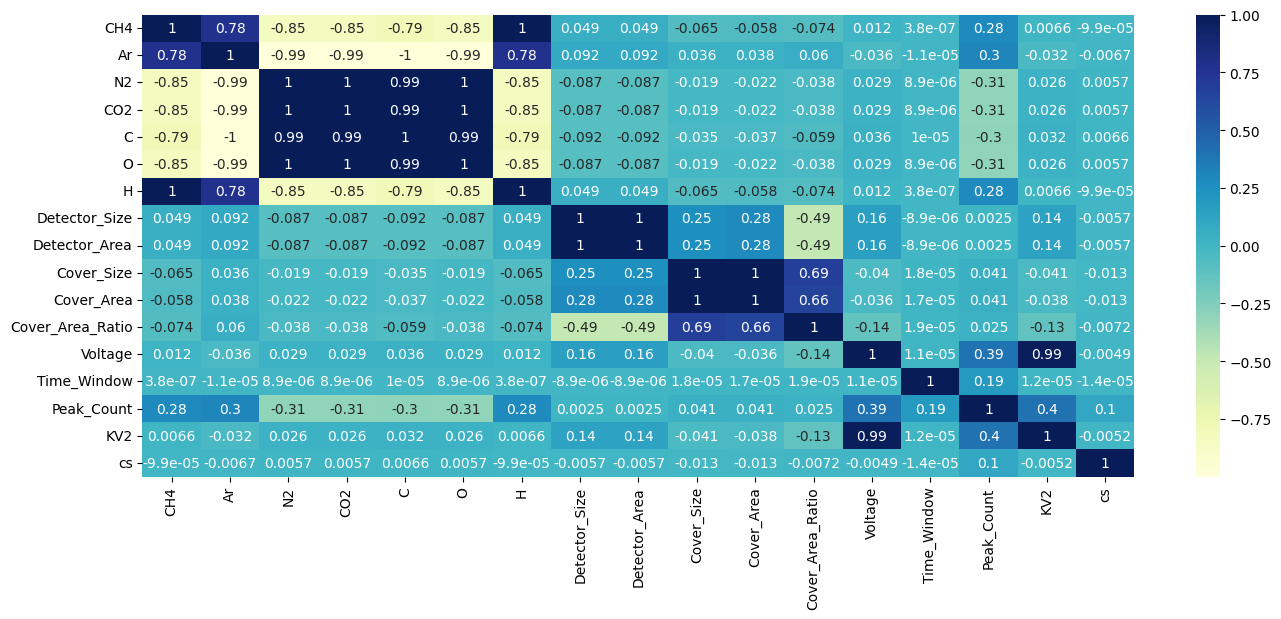

In [19]:
# creation of correlation matrix
corrM = data.corr()
plt.figure(figsize=(16, 6))
dataplot = sns.heatmap(corrM, cmap="YlGnBu", annot=True) 


In [20]:
corr = corrM[abs(corrM['Peak_Count'])>0.1][['Peak_Count']]
list(corr.index)

['CH4',
 'Ar',
 'N2',
 'CO2',
 'C',
 'O',
 'H',
 'Voltage',
 'Time_Window',
 'Peak_Count',
 'KV2',
 'cs']

In [21]:
#data=data[list(corr.index)]
data

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,KV2,cs
4232,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,7500,10,21,56.25,0.0
57113,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,7000,15,215,49.00,1.0
4234,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,7500,15,27,56.25,0.0
56639,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,4500,15,10,20.25,0.0
61122,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,8000,15,33,64.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100996,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,6000,10,0,36.00,0.0
19322,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,7500,10,166,56.25,1.0
8961,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,4.00,16.00,0.16,3000,15,12,9.00,1.0
91798,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,7000,10,4,49.00,1.0


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x=data.drop(['Peak_Count'],axis=1)

x.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,cs
4232,0.1,0.9,0.0,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,7500,10,56.25,0.0
57113,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,100.0,4.0,16.0,0.16,7000,15,49.00,1.0
4234,0.1,0.9,0.0,0.0,0.02,0.0,0.08,10.0,100.0,6.0,36.0,0.36,7500,15,56.25,0.0
56639,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,100.0,4.0,16.0,0.16,4500,15,20.25,0.0
61122,0.2,0.8,0.0,0.0,0.04,0.0,0.16,10.0,100.0,8.0,64.0,0.64,8000,15,64.00,0.0


In [24]:
y=data['Peak_Count']
y

4232       21
57113     215
4234       27
56639      10
61122      33
         ... 
100996      0
19322     166
8961       12
91798       4
52857      57
Name: Peak_Count, Length: 7370, dtype: int64

In [25]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
model=LinearRegression()

In [28]:
model.fit(X_train,y_train)

LinearRegression()

In [29]:
pred=model.predict(X_test)
pred

array([-101.73123563,   45.73388154,  316.61676138, ...,  -51.62092066,
        -10.02816913,    6.15992668])

In [30]:
y_test

86613      0
91560      2
13197    250
64659      0
88265      0
        ... 
24041      4
96521      0
8239      12
92976      2
94163      3
Name: Peak_Count, Length: 1474, dtype: int64

In [31]:
X_test

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,cs
86613,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,3000,15,9.00,1.0
91560,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,6500,10,42.25,1.0
13197,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,8.00,64.00,0.64,7500,15,56.25,1.0
64659,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,2500,10,6.25,1.0
88265,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,4.00,16.00,0.16,6500,15,42.25,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24041,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,4000,10,16.00,1.0
96521,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,4000,15,16.00,0.0
8239,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,4.00,16.00,0.16,3000,10,9.00,0.0
92976,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,5500,10,30.25,1.0


In [32]:
model.score(X_test, y_test)

0.3461637215819604

In [33]:
pred

array([-101.73123563,   45.73388154,  316.61676138, ...,  -51.62092066,
        -10.02816913,    6.15992668])

In [34]:
y_test

86613      0
91560      2
13197    250
64659      0
88265      0
        ... 
24041      4
96521      0
8239      12
92976      2
94163      3
Name: Peak_Count, Length: 1474, dtype: int64

In [35]:
indexes = X_test.index.values
#index=indexes[98]

In [36]:
#X_test.loc[index]

In [37]:
#y_test[index],pred[98]
pred[pred<=0] = 0

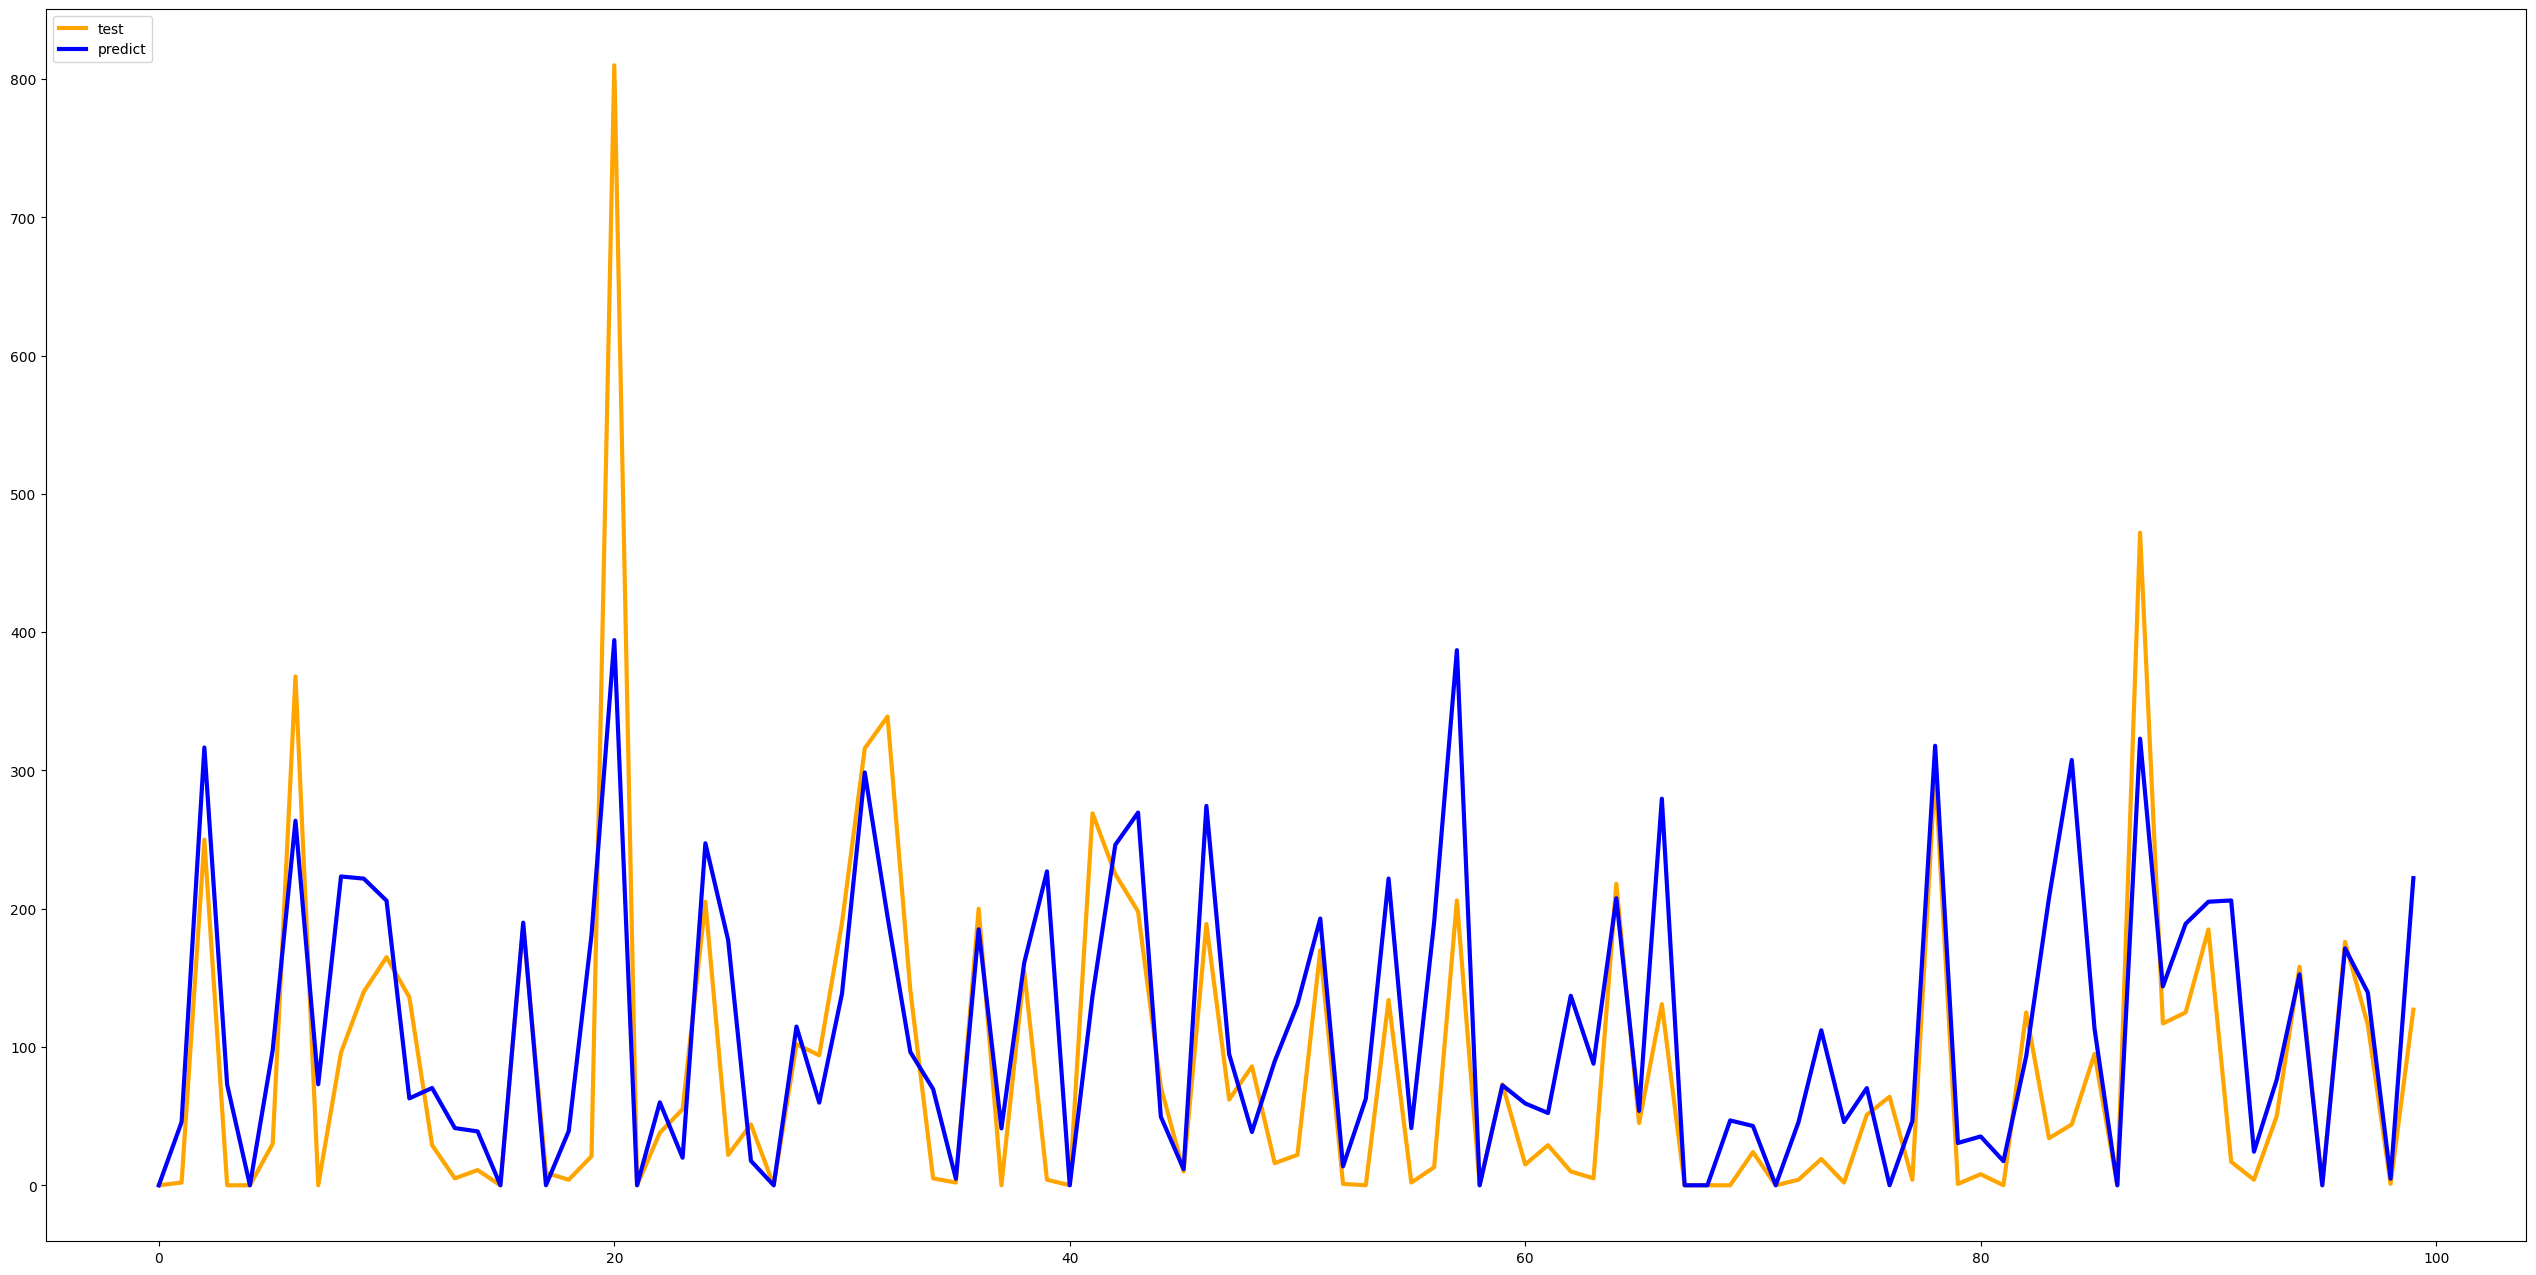

In [38]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(indexes))[:100],y_test[:100], color="orange", linewidth=3 ,label = 'test')
plt.plot(range(0,len(indexes))[:100],pred[:100], color="blue", linewidth=3,label = 'predict')
plt.legend(loc="upper left")
plt.show()

In [39]:
indexes = X_test.index.values
#index=indexes[98]

In [40]:
#X_test.loc[index]

In [41]:
#y_test[index],pred[98]

In [42]:
#metrics.mean_absolute_error(y_true, y_pred, *) -> Mean absolute error regression loss.
metrics.mean_absolute_error(y_test, pred)

68.49633388247646

In [43]:
#metrics.mean_squared_error(y_true, y_pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred)

23803.471330340395

In [44]:
#metrics.mean_squared_error(y_true, pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred)**0.5

154.2837364414681

In [45]:
#metrics.mean_absolute_percentage_error(...) -> Mean absolute percentage error (MAPE) regression loss.
metrics.mean_absolute_percentage_error(y_test, pred)

2.4966946879628816e+16

In [46]:
#metrics.r2_score(y_true, y_pred, *[, ...]) -> (coefficient of determination) regression score function.
metrics.r2_score(y_test, pred)

0.37108805329753625

In [47]:
metrics.explained_variance_score(y_test, pred)

0.374230934505431

In [48]:
from pyGRNN import GRNN

In [49]:
model_grnn = GRNN(sigma=5)

In [50]:
#dbfile = open('grnn_model.pickle', 'ab')
#pickle.dump(model_grnn, dbfile)                    
#dbfile.close()

In [51]:
with (open("grnn_model.pickle", "rb")) as openfile:
    model_grnn=pickle.load(openfile)

#model_grnn.fit(X_train,y_train)

In [52]:
pred_grnn=model_grnn.predict(X_test)
pred_grnn

array([2.59349772e-13, 1.72167801e+01, 2.61491039e+02, ...,
       9.12282459e+00, 9.62845200e+00, 2.31473953e+01])

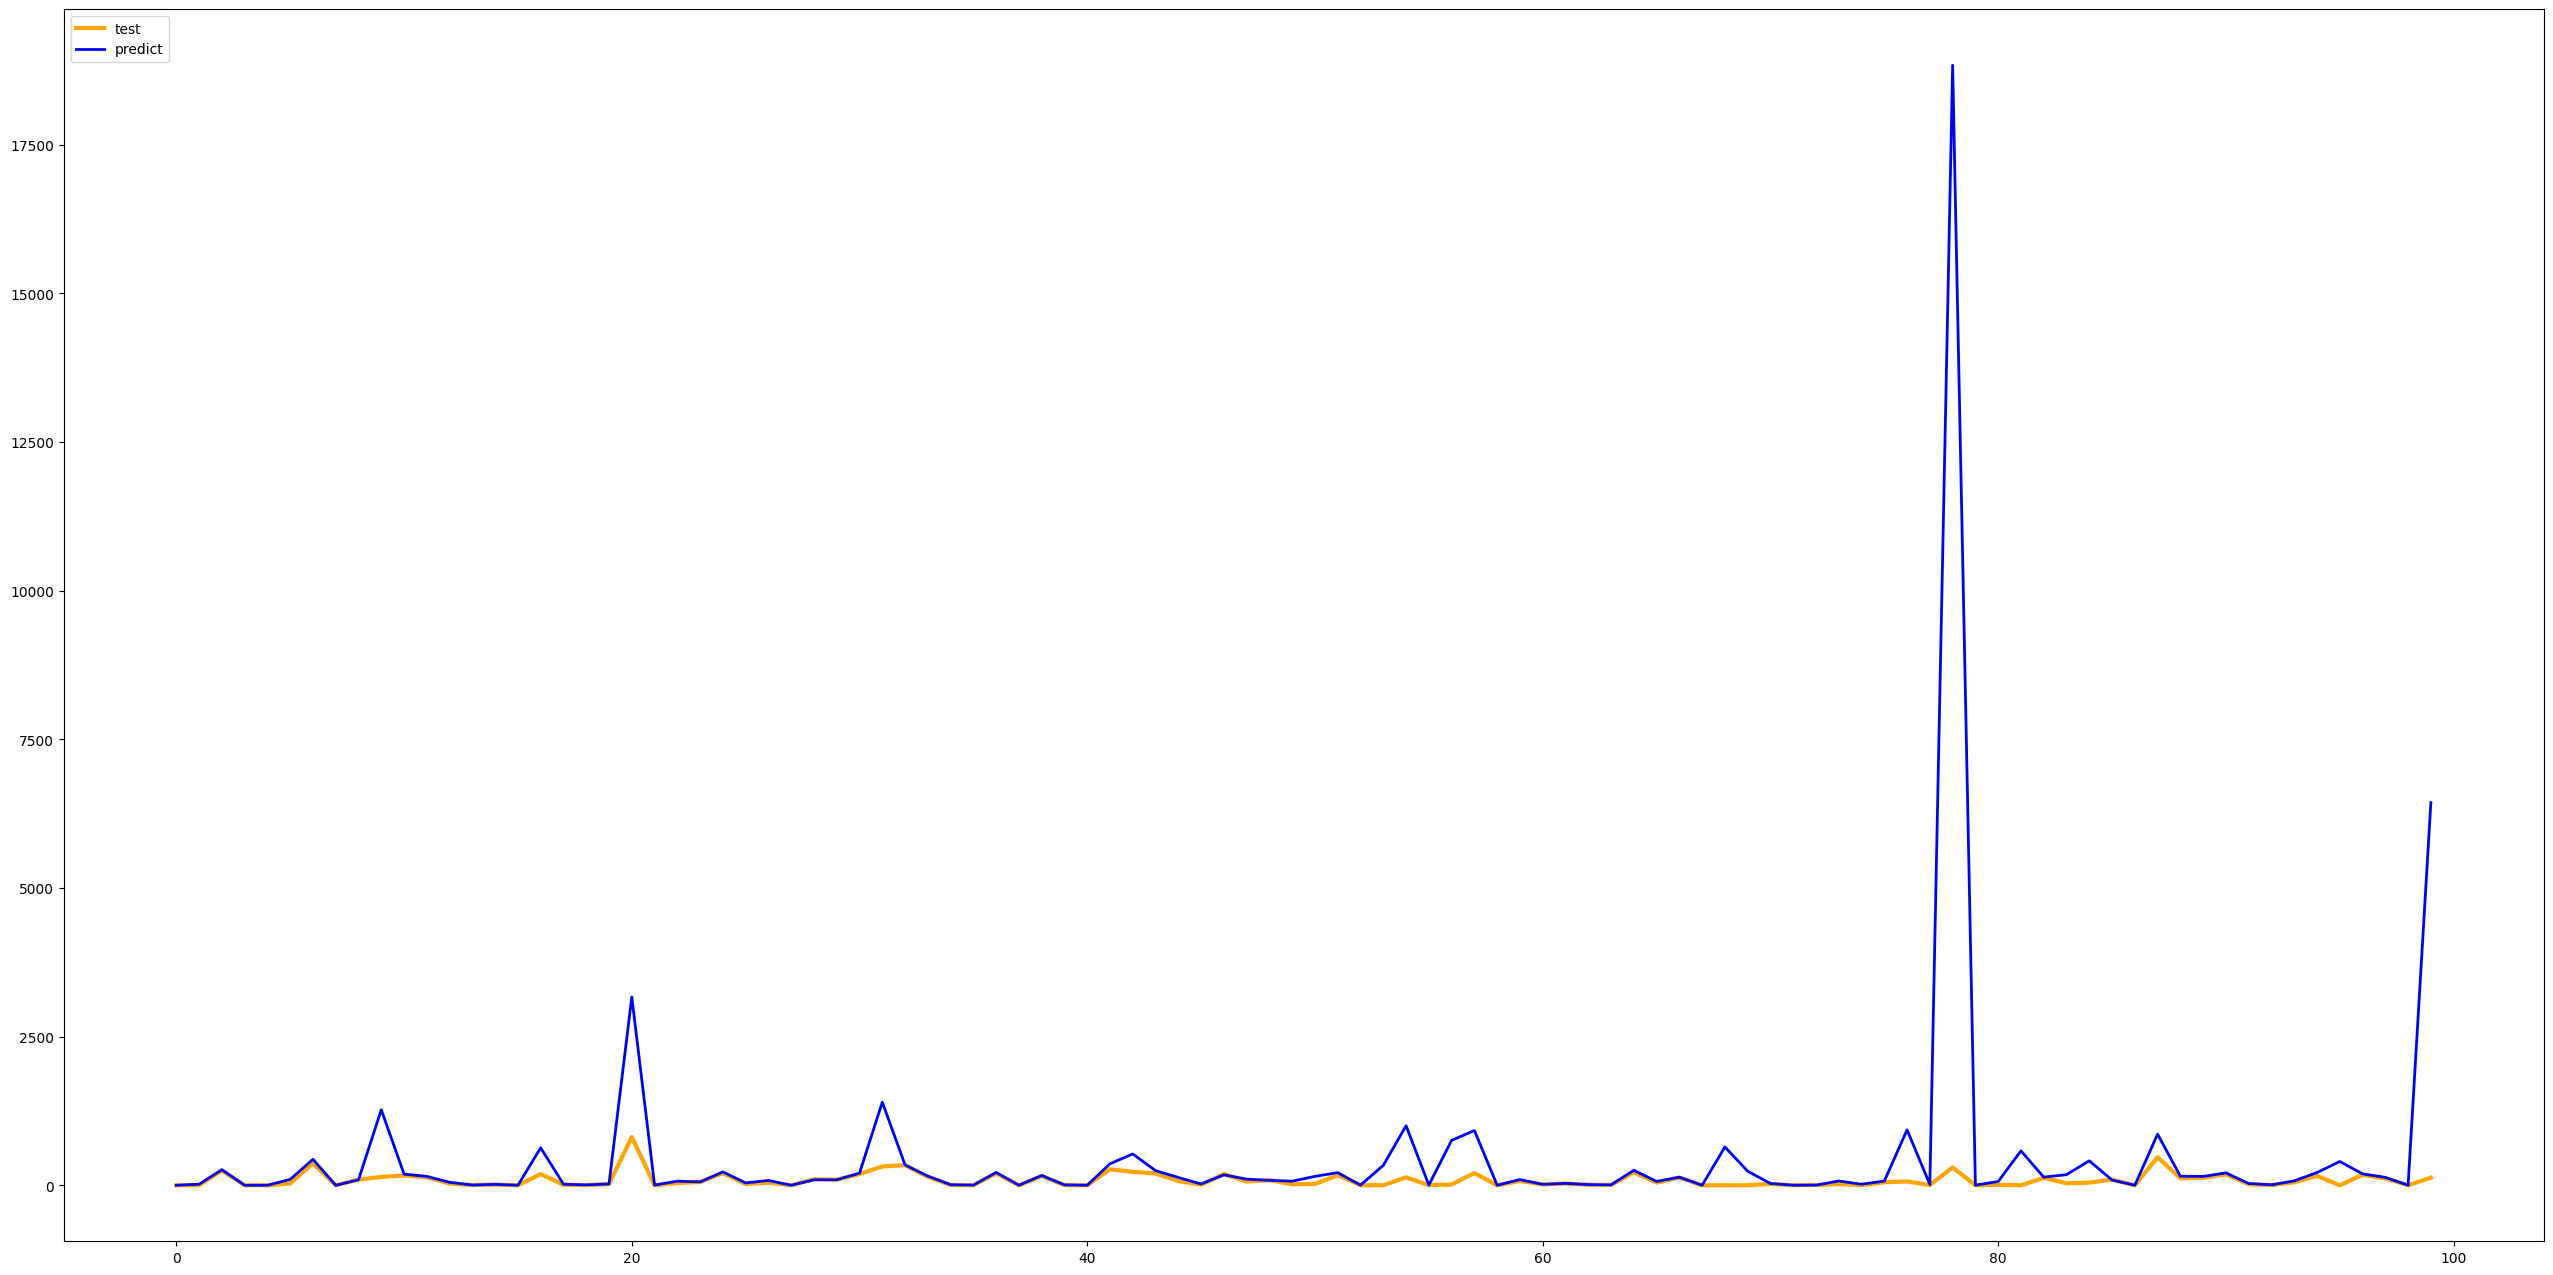

In [53]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(indexes))[:100],y_test[:100], color="orange", linewidth=3 ,label = 'test')
plt.plot(range(0,len(indexes))[:100],pred_grnn[:100], color="blue", linewidth=2,label = 'predict')
plt.legend(loc="upper left")
plt.show()

In [54]:
X_test['olcum'] = y_test
X_test['tahmin'] = pred_grnn
X_test

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,cs,olcum,tahmin
86613,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,3000,15,9.00,1.0,0,2.593498e-13
91560,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,6500,10,42.25,1.0,2,1.721678e+01
13197,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,8.00,64.00,0.64,7500,15,56.25,1.0,250,2.614910e+02
64659,0.2,0.80,0.00,0.0,0.04,0.0,0.16,6.78,45.97,4.78,22.85,0.50,2500,10,6.25,1.0,0,2.016088e-02
88265,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,4.00,16.00,0.16,6500,15,42.25,1.0,0,2.185603e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24041,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,4000,10,16.00,1.0,4,7.052535e+00
96521,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,4000,15,16.00,0.0,0,7.956402e+02
8239,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,4.00,16.00,0.16,3000,10,9.00,0.0,12,9.122825e+00
92976,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,5500,10,30.25,1.0,2,9.628452e+00


In [55]:
#metrics.mean_absolute_error(y_true, y_pred, *) -> Mean absolute error regression loss.
metrics.mean_absolute_error(y_test, pred_grnn)

207.7737157400235

In [56]:
#metrics.mean_squared_error(y_true, y_pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred_grnn)

868400.0804216965

In [57]:
#metrics.mean_squared_error(y_true, pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred_grnn)**0.5

931.8798637279897

In [58]:
#metrics.mean_absolute_percentage_error(...) -> Mean absolute percentage error (MAPE) regression loss.
metrics.mean_absolute_percentage_error(y_test, pred_grnn)

2.59035915396161e+17

In [59]:
#metrics.r2_score(y_true, y_pred, *[, ...]) -> (coefficient of determination) regression score function.
metrics.r2_score(y_test, pred_grnn)

-21.944014237051835

In [60]:
metrics.explained_variance_score(y_test, pred_grnn)

-20.850129468457023

In [61]:
row = data.loc[data.index.values[0]]
row

CH4                    0.10
Ar                     0.90
N2                     0.00
CO2                    0.00
C                      0.02
O                      0.00
H                      0.08
Detector_Size         10.00
Detector_Area        100.00
Cover_Size             6.00
Cover_Area            36.00
Cover_Area_Ratio       0.36
Voltage             7500.00
Time_Window           10.00
Peak_Count            21.00
KV2                   56.25
cs                     0.00
Name: 4232, dtype: float64

In [62]:
row = dict(row)
row

{'CH4': 0.1,
 'Ar': 0.9,
 'N2': 0.0,
 'CO2': 0.0,
 'C': 0.02,
 'O': 0.0,
 'H': 0.08,
 'Detector_Size': 10.0,
 'Detector_Area': 100.0,
 'Cover_Size': 6.0,
 'Cover_Area': 36.0,
 'Cover_Area_Ratio': 0.36,
 'Voltage': 7500.0,
 'Time_Window': 10.0,
 'Peak_Count': 21.0,
 'KV2': 56.25,
 'cs': 0.0}

In [63]:
row = {'CH4': 0.3,
 'Ar': 0.7,
 'N2': 0.0,
 'CO2': 0.0,
 'C': 0.06,
 'O': 0.0,
 'H': 0.24,
 'Detector_Size': 10.0,
 'Detector_Area': 100.0,
 'Cover_Size': 8.0,
 'Cover_Area': 64.0,
 'Cover_Area_Ratio': 0.64,
 'Voltage': 7000.0,
 'Time_Window': 15.0,
 'KV2': 12.25,
 'cs': 1.0}
df = pd.DataFrame.from_dict(row,orient='index').T
df

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,cs
0,0.3,0.7,0.0,0.0,0.06,0.0,0.24,10.0,100.0,8.0,64.0,0.64,7000.0,15.0,12.25,1.0


In [64]:
model_grnn.predict(df)

array([129.78362268])